In [1]:
import pandas as pd
import numpy as np
from hdr_adjustments import hdr_adjustment
import matplotlib.pyplot as plt
from skimage import io
from matplotlib.colors import ListedColormap, BoundaryNorm
from preprocess_point_cloud import preprocess_point_cloud
from pathlib import Path
from plot_tools import get_image_histogram, display_unwrapped_single_band_images, display_unwrapped_rgb_image, display_single_band_img_wt_discrete_values
from norm_to_hsv import attach_normal_color_to_df

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Ignore warnings
pd.options.mode.chained_assignment = None  # Disable the warning

## Initialize Input Paths

In [3]:
# In zmachine (linux)
# key_str = "UMBCBL009_2024-03-28-00-35-40_AURSET3NorthU_060180_003712.800_1151376296"
# key_str2 = "AURSET3"
# output_dir = Path(f'/home/fzhcis/mylab/data/point_cloud_segmentation/unwrap_outputs/{key_str2}/{key_str}')


# In amiri (windows)
key_str = "33_01"
key_str2 = "harvard_forest_33"
# output_dir = Path(fr'G:\My Drive\projects_with_Jan\point_cloud_segmentation\unwrap_outputs\{key_str2}\{key_str}')
output_dir = Path(fr'/home/fzhcis/mylab/gdrive/projects_with_Jan/point_cloud_segmentation/unwrap_outputs/{key_str2}/{key_str}')

filename = output_dir / f'{key_str}_filtered_normaled_treeiso.txt'
saveflag = True
upside_down = False # if the lidar was installed upside down; True for roots, False for tree trunk.


In [4]:
AZIMUTH_NORM_SCALE = 360
ZENITH_NORM_SCALE = 135
# Since degree resolution=0.25: 360/0.25=1440
CANVAS_WIDTH = 1440 
CANVAS_HEIGHT = 540

## Preprocess the Point Cloud data
- read the data as a pandas dataframe
- Clean it
  - Filter with first return and non-extreme intensity values
- prepare x_pix and y_pix columns for grouping

## Prepare the functions for displaying images.

### Observe the density map and histograms

In [5]:
def unwrap_point_cloud_to_2d_images(filename: str, hdr_method: str = 'clahe', upside_down=True) -> tuple[pd.DataFrame, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel value with different kinds of scalar fields.
    Including density, intensity, range, and range-xy images.

    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    hdr_method (str): The HDR adjustment hdr_method to apply. Default is 'clahe'.
    saveflag (bool): If True, save the images to the output_dir directory. Default is True.

    Returns:
    df_filtered (pd.DataFrame): A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: A tuple containing the density image, adjusted intensity image, adjusted range image, and adjusted range-xy image.
    """
    # Step 5: Fill in the canvas pixels with scalar field values
    ## Preprocess the point cloud data
    df_filtered = preprocess_point_cloud(filename, upside_down=upside_down)
    df_filtered_ncolored = attach_normal_color_to_df(df_filtered)
    df_filtered_ncolored['range1metres'] = df_filtered_ncolored['range1metres'].max() - df_filtered_ncolored['range1metres']  # reverse the range values
    df_filtered_ncolored['Z'] = df_filtered_ncolored['Z'].max() - df_filtered_ncolored['Z']  # reverse the Z values
    grouped = df_filtered_ncolored.groupby(['y_pix', 'x_pix'])

    ## Compute intensity and range per pixel. 
    ## Since less than 0.1% of the pixels contain more than one point, it doesn't matter if we use mean or max.
    group_intensity = grouped['Intensity'].mean()
    group_range = grouped['range1metres'].max()
    pts_per_pixel = grouped.size()
    z_value_per_pixel = grouped['Z'].mean().abs()
    seg_id_per_pixel = grouped['treeiso_label'].max()
    # curvature_per_pixel = grouped['curvature'].mean()
    # roughness_per_pixel = grouped['roughness'].mean()
    
    range_x = grouped['X'].mean()
    range_y = grouped['Y'].mean()
    range_xy = np.sqrt(range_x**2 + range_y**2)

    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    z_value_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    intensity_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_xy_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)  # range in xy plane
    density_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    treeiso_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    # curvature_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    # roughness_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    
    pxpy_indices = np.array(group_intensity.index.tolist())
    intensity_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_intensity.values
    range_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_range.values
    density_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = pts_per_pixel.values
    range_xy_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = range_xy.values
    z_value_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = z_value_per_pixel.values
    treeiso_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = seg_id_per_pixel.values
    # curvature_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = curvature_per_pixel.values
    # roughness_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = roughness_per_pixel.values


    # Step 6: Apply HDR adjustment to intensity and range images
    intensity_image_adjusted = hdr_adjustment(intensity_image, method='clahe')
    range_image_adjusted = hdr_adjustment(range_image, method=hdr_method)
    range_xy_image_adjusted = hdr_adjustment(range_xy_image, method=hdr_method)
    z_value_image_adjusted = hdr_adjustment(z_value_image, method=hdr_method)
    # curvature_image_adjusted = hdr_adjustment(curvature_image, method=hdr_method)
    # roughness_image_adjusted = hdr_adjustment(roughness_image, method=hdr_method)

    output_images = (density_image, 
                     intensity_image_adjusted, 
                     range_image_adjusted, 
                     range_xy_image_adjusted, 
                     z_value_image_adjusted, 
                    #  curvature_image_adjusted,
                    #  roughness_image_adjusted,
                     intensity_image, 
                     range_image, 
                     range_xy_image, 
                     z_value_image,
                     treeiso_image,
                    #  curvature_image,
                    #  roughness_image,
                     )
   
    return df_filtered_ncolored, output_images


In [6]:
def unwrap_pc_normals_to_rgb_image(df_filtered_ncolored: pd.DataFrame) -> np.ndarray:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel values
    colorized by the normal vectors.

    Parameters:
    
    """
    grouped = df_filtered_ncolored.groupby(['y_pix', 'x_pix'])

    r_per_pixel = grouped['n_r'].mean()
    g_per_pixel = grouped['n_g'].mean()
    b_per_pixel = grouped['n_b'].mean()


    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    r_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    g_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    b_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    
    pxpy_indices = np.array(r_per_pixel.index.tolist())
    r_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = r_per_pixel.values
    g_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = g_per_pixel.values
    b_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = b_per_pixel.values

    # Stack the single channel images to create an RGB image
    rgb_image = np.stack((r_image, g_image, b_image), axis=-1) # Shape: (540, 1440, 3)
   
    return rgb_image

## Run the above process
- display density map and density histogram
- display Intensity Map, Range Map, and Range-XY Map

Header detected.


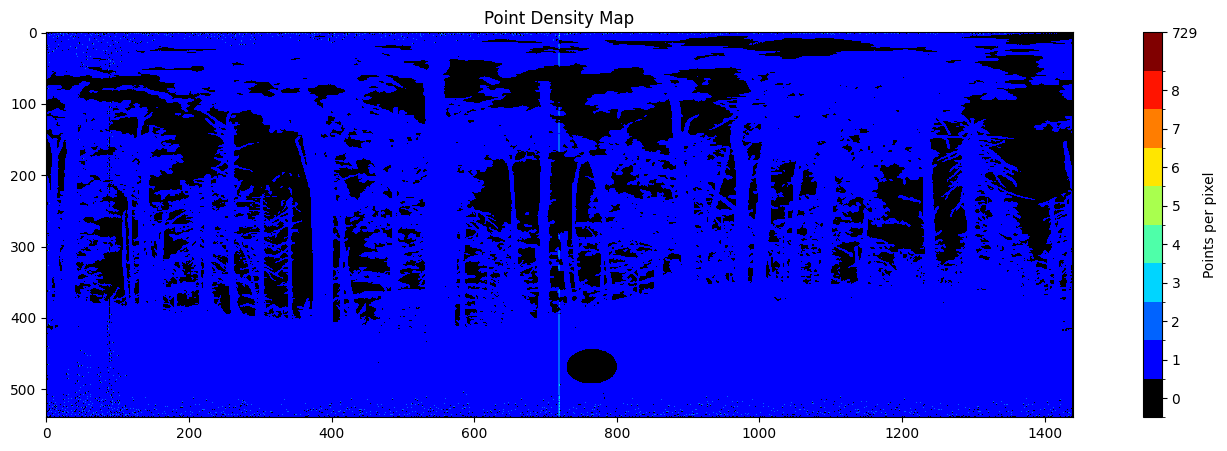

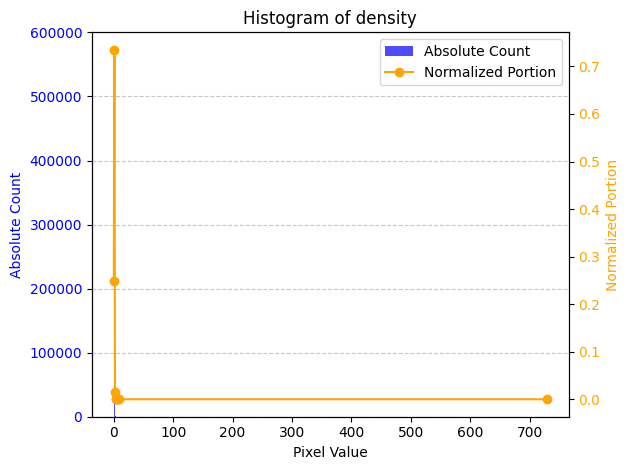

Histogram:
Values: [  0.   1.   2.   3.   4.   5.   6.   7.   8. 729.]
Counts: [192614 571525  12110    358    206    737     38      6      5      1]
Normalized Counts: [0.248 0.735 0.016 0.    0.    0.001 0.    0.    0.    0.   ]


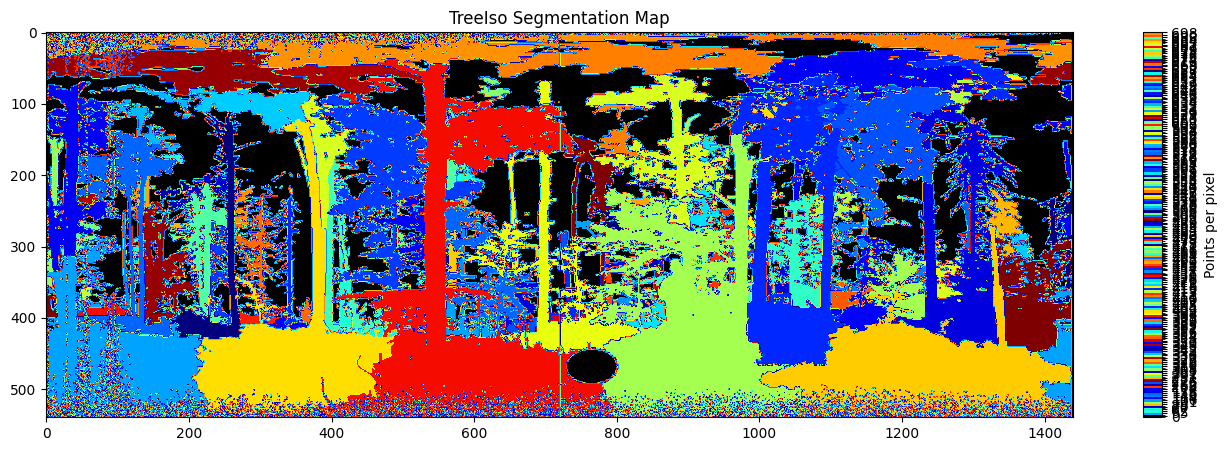

Images saved to /home/fzhcis/mylab/gdrive/projects_with_Jan/point_cloud_segmentation/unwrap_outputs/harvard_forest_33/33_01 directory


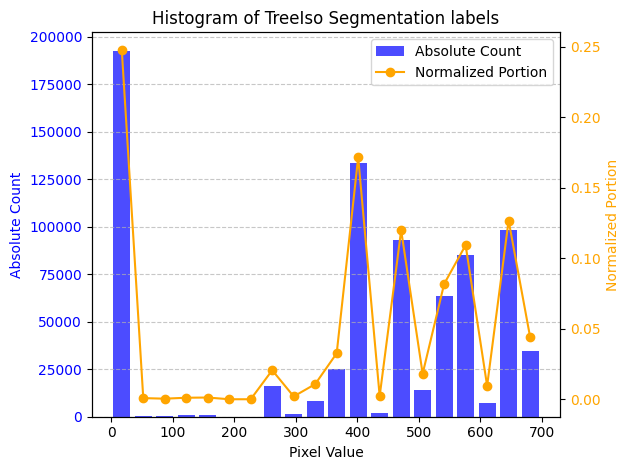

Histogram:
Values: [ 17.45      52.350002  87.25     122.15     157.05     191.95
 226.85     261.75     296.65002  331.55     366.45     401.34998
 436.25     471.15002  506.05     540.95     575.85     610.75
 645.65     680.55    ]
Counts: [192614    636    313    836    948      0      0  15997   1544   8347
  25319 133363   1760  93152  14066  63552  84941   7387  98484  34341]
Normalized Counts: [0.248 0.001 0.    0.001 0.001 0.    0.    0.021 0.002 0.011 0.033 0.172
 0.002 0.12  0.018 0.082 0.109 0.009 0.127 0.044]


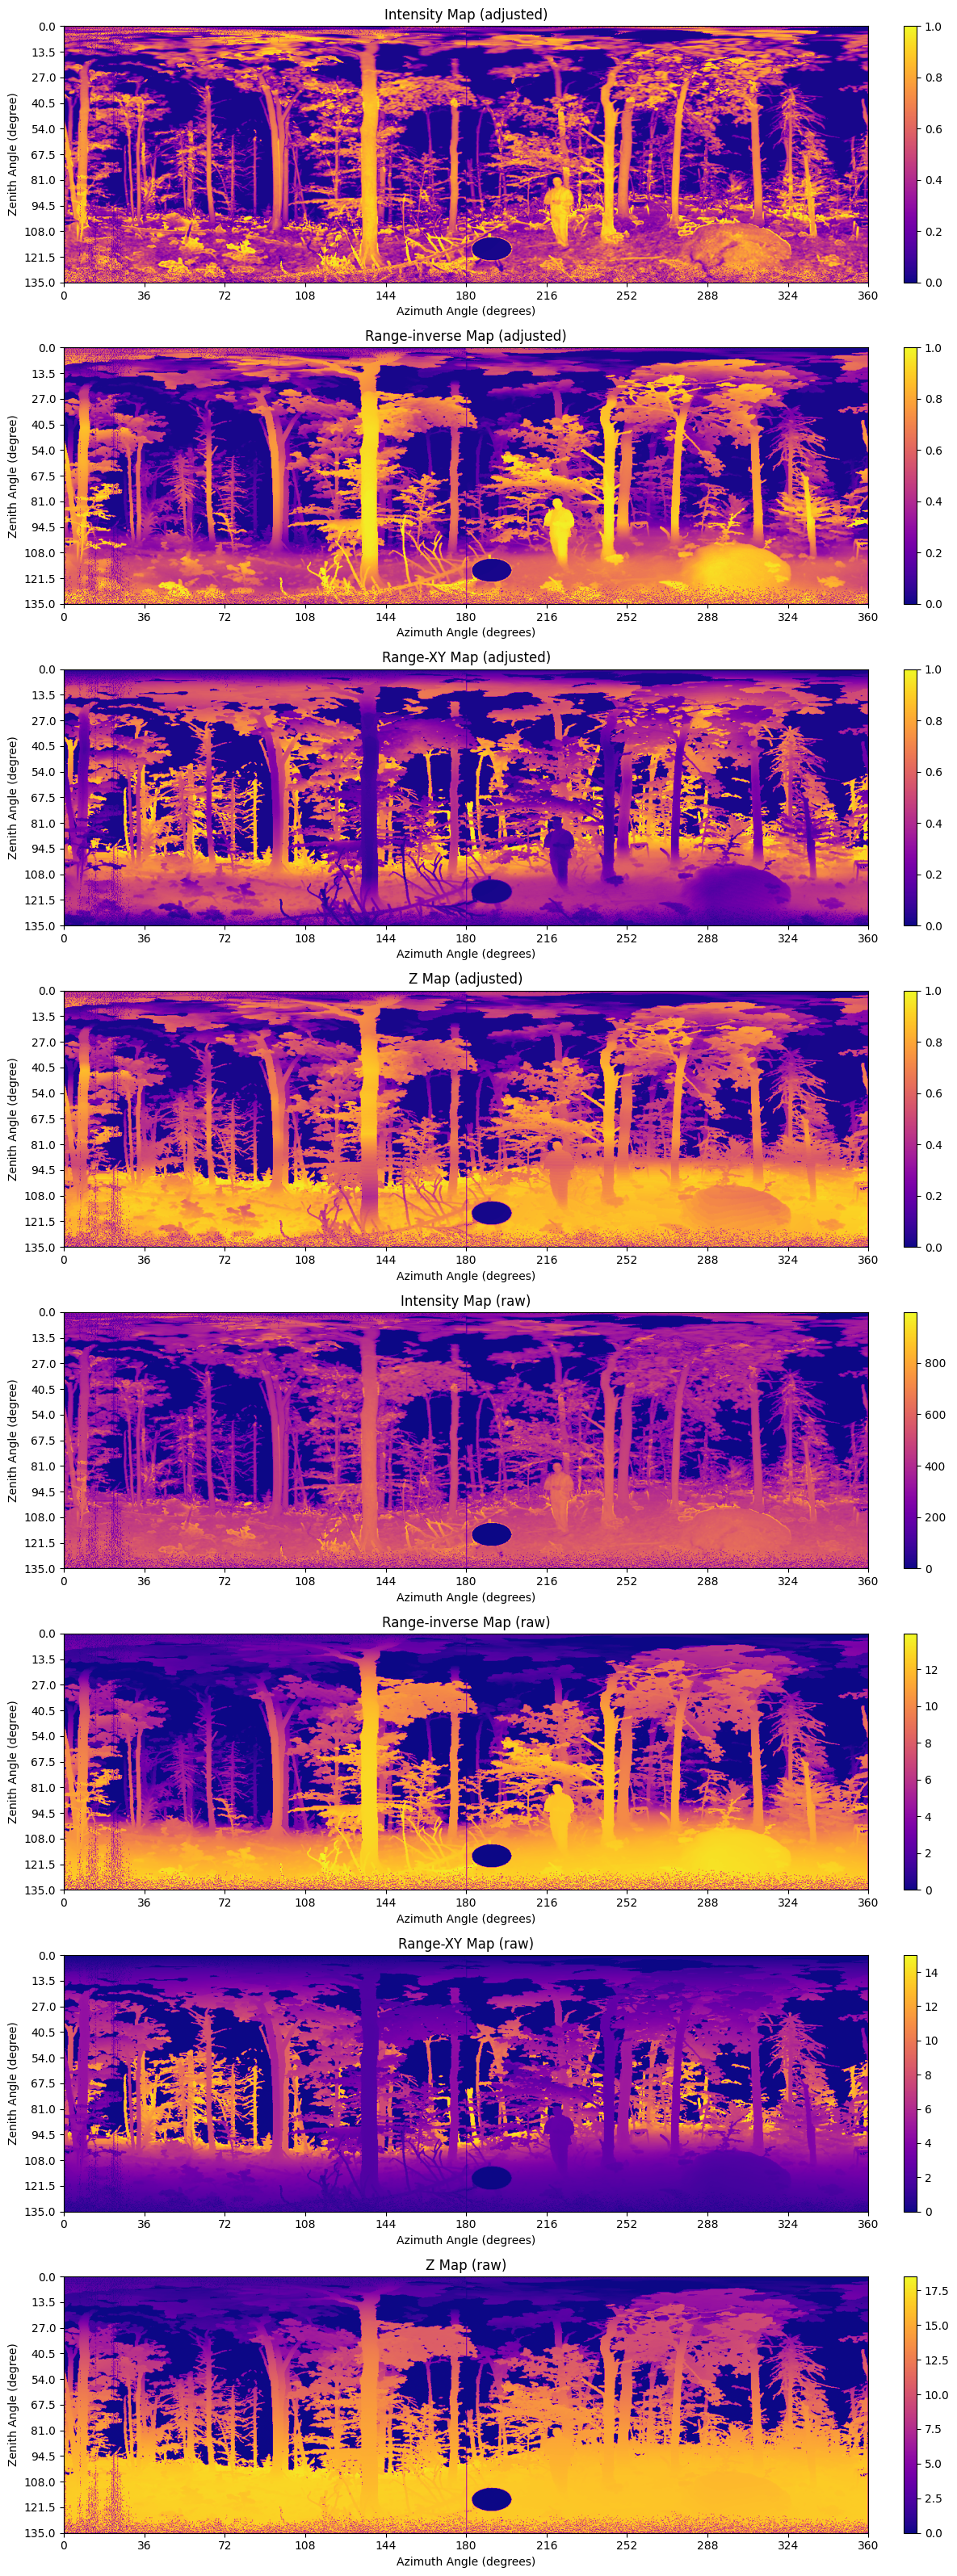

Images saved to /home/fzhcis/mylab/gdrive/projects_with_Jan/point_cloud_segmentation/unwrap_outputs/harvard_forest_33/33_01 directory


In [7]:
df_filtered, output_images = unwrap_point_cloud_to_2d_images(filename, hdr_method='clahe', upside_down=upside_down)
density_image = output_images[0]
seg_map = output_images[-1]
titles = ['Density Map', 
          'Intensity Map (adjusted)', 
          'Range-inverse Map (adjusted)', 
          'Range-XY Map (adjusted)', 
          'Z Map (adjusted)', 
        #   'Curvature Map (adjusted)',
        #   'Roughness Map (adjusted)',
          'Intensity Map (raw)', 
          'Range-inverse Map (raw)', 
          'Range-XY Map (raw)', 
          'Z Map (raw)',
          'TreeIso Segmentation Map',
        #   'Curvature Map (raw)',
        #   'Roughness Map (raw)',
          ]
# display_density_images(density_image, saveflag=False)
display_single_band_img_wt_discrete_values(density_image, title='Point Density Map', output_dir=output_dir, saveflag=False)
get_image_histogram(image_data=density_image, 
                    title='density', 
                    saveflag=False, 
                    output_dir=output_dir)

display_single_band_img_wt_discrete_values(seg_map, title='TreeIso Segmentation Map', output_dir=output_dir, saveflag=saveflag)
get_image_histogram(image_data=seg_map, 
                    title='TreeIso Segmentation labels', 
                    saveflag=False, 
                    output_dir=output_dir)


# Step 7: Display and save the adjusted intensity and range images
display_unwrapped_single_band_images(output_images[1:-1], 
                                    titles=titles[1:-1],
                                    output_dir=output_dir,
                                    saveflag=saveflag,
                                    upside_down=upside_down)



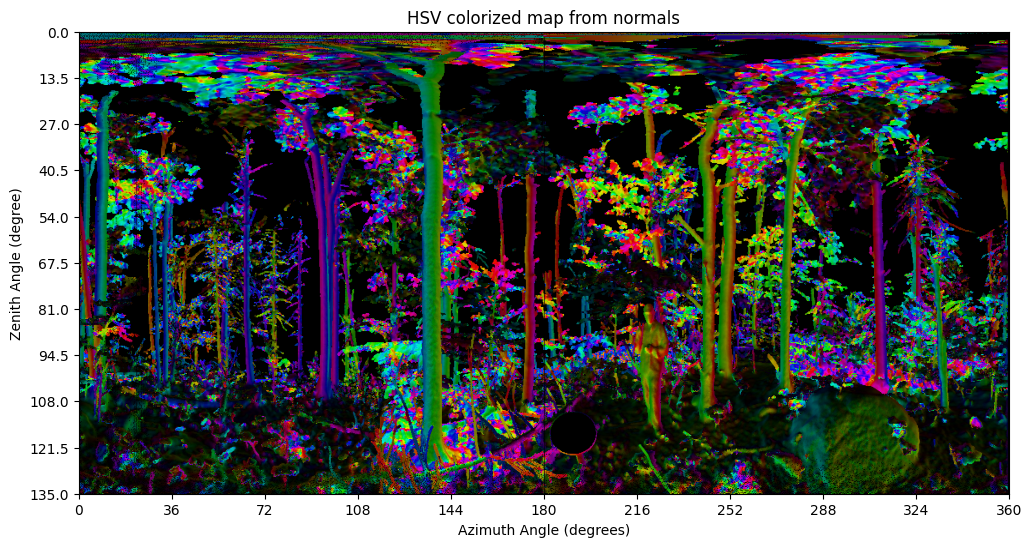

In [8]:
# Display the normals colorized RGB image.
normals_rgb_image = unwrap_pc_normals_to_rgb_image(df_filtered)
display_unwrapped_rgb_image(normals_rgb_image, 
                            figure_title='HSV colorized map from normals', 
                            saveflag=saveflag, 
                            output_dir=output_dir,
                            upside_down=upside_down)

In [9]:
# for hist_image, title in zip(output_images, titles):
#     get_image_histogram(image_data=hist_image, title=title, saveflag=False, output_dir=output_dir)

## Combine Unwrapped images to an psudo-RGB image

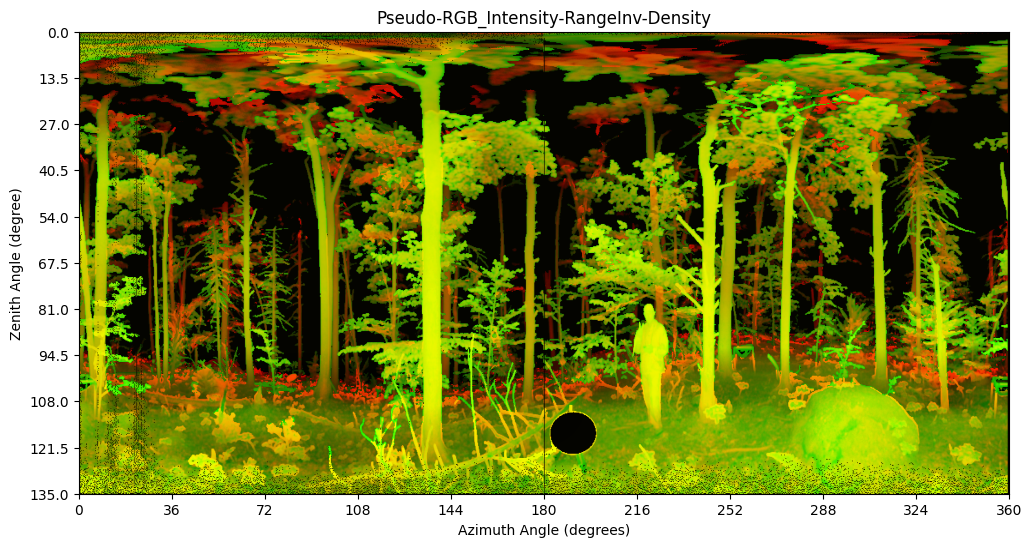

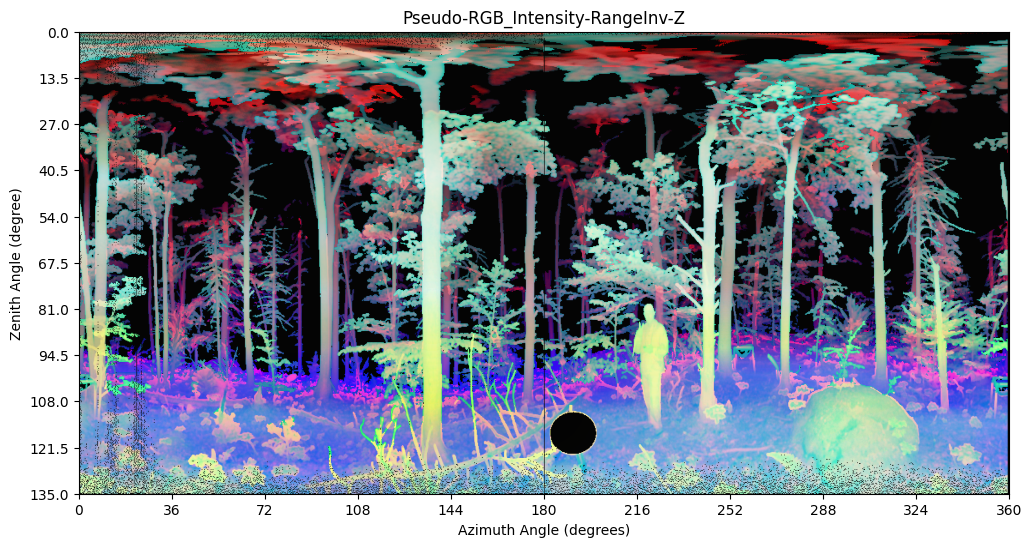

In [10]:
def create_pseudo_rgb_image(intensity_image: np.ndarray, 
                            range_image: np.ndarray, 
                            third_channel_img: np.ndarray, 
                            figure_title: str = '',
                            saveflag:bool=False,
                            upside_down:bool = False) -> np.ndarray:
    """
    Combine intensity, range, and density images into a pseudo-RGB image.

    Parameters:
    -----------
    intensity_image : np.ndarray
        The adjusted intensity image.
    range_image : np.ndarray
        The adjusted range image.
    third_channel_img : np.ndarray
        The third channel image, can be the density map, z-value map, or any other scalar field.

    Returns:
    --------
    np.ndarray
        The pseudo-RGB image.
    """
    # Normalize the images to the range [0, 1]
    intensity_norm = (intensity_image - intensity_image.min()) / (intensity_image.max() - intensity_image.min())
    range_norm = (range_image - range_image.min()) / (range_image.max() - range_image.min())
    third_channel_img_norm = (third_channel_img - third_channel_img.min()) / (third_channel_img.max() - third_channel_img.min())

    # Stack the normalized images to create an RGB image
    pseudo_rgb_image = np.stack((intensity_norm, range_norm, third_channel_img_norm), axis=-1)
    display_unwrapped_rgb_image(pseudo_rgb_image, 
                            figure_title, 
                            output_dir, 
                            saveflag,
                            upside_down,
                            )

    return pseudo_rgb_image

# Create the pseudo-RGB image
figure_title_1 = 'Pseudo-RGB_Intensity-RangeInv-Density'
figure_title_2 = 'Pseudo-RGB_Intensity-RangeInv-Z'
figure_title_3 = 'Pseudo-RGB_Intensity-Range-Curvature'
figure_title_4 = 'Pseudo-RGB_Intensity-Range-Roughness'
# density_image, intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted, curvature_image_adjusted, roughness_image_adjusted = output_images[0], output_images[1], output_images[2], output_images[4], output_images[5], output_images[6]
density_image, intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted = output_images[0], output_images[1], output_images[2], output_images[4]
pseudo_rgb_image_1 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, density_image, figure_title_1, saveflag=False, upside_down=upside_down)
pseudo_rgb_image_2 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted, figure_title_2, saveflag=saveflag, upside_down=upside_down)
# pseudo_rgb_image_3 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, curvature_image_adjusted, figure_title_3, saveflag=saveflag)
# pseudo_rgb_image_4 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, roughness_image_adjusted, figure_title_4, saveflag=saveflag)

